<a href="https://colab.research.google.com/github/ddeamanda/-Text-Classification/blob/main/%5BCODE%5D_UTS_Analisis_Data_Tak_Terstruktur_Dede_Amanda_Julieta_(2206810111).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**UTS ANALISIS DATA TIDAK TERSTRUKTUR**

DIBUAT OLEH : DEDE AMANDA JULIETA (2206810111)


In [169]:
!pip install google-play-scraper pandas

In [170]:
from google_play_scraper import Sort, reviews
import pandas as pd

# --- 1. PROSES SCRAPING ---
print("Akan diambil ulasan...")
result, continuation_token = reviews(
    'com.zhiliaoapp.musically', # Ini adalah ID aplikasi TikTok di Play Store
    lang='id',                  # Mengambil ulasan berbahasa Indonesia
    country='id',               # Dari region Indonesia
    sort=Sort.NEWEST,           # Mengurutkan dari ulasan paling baru
    count=100000                 # Jumlah ulasan yang ditarik (bisa diperbesar sesuai kebutuhan)
)

# Mengubah hasil scraping menjadi DataFrame (tabel)
df = pd.DataFrame(result)
print(f"Total ulasan TikTok mentah yang ditarik: {len(df)}")

# --- 2. PROSES FILTERING (KHUSUS TIKTOK SHOP) ---
# Menentukan kata kunci yang relevan dengan pengalaman belanja
keywords = ['shop', 'belanja', 'keranjang', 'ongkir', 'seller', 'pesanan',
            'pengiriman', 'paket', 'toko', 'barang', 'kurir', 'cod']
pattern = '|'.join(keywords)

# Menyaring ulasan agar hanya menampilkan yang mengandung kata kunci di atas (tidak case-sensitive)
df_shop = df[df['content'].str.contains(pattern, case=False, na=False)]

# Hanya mengambil kolom yang penting untuk analisis
df_shop_bersih = df_shop[['userName', 'score', 'at', 'content']]

# --- 3. MENYIMPAN DATA ---
# Menyimpan dataset yang sudah difilter ke format CSV
df_shop_bersih.to_csv('dataset_tiktok_shop_playstore.csv', index=False)
print(f"Total ulasan terkait TikTok Shop setelah difilter: {len(df_shop_bersih)}")

Akan diambil ulasan...
Total ulasan TikTok mentah yang ditarik: 100000
Total ulasan terkait TikTok Shop setelah difilter: 297


In [171]:
df=pd.read_csv('dataset_tiktok_shop_playstore.csv')
display(df)

,userName,score,at,content
0,Pengguna Google,3,2026-03-04 10:49:10,mengapa tidak ada etalase keranjang kuningnya
1,Pengguna Google,2,2026-02-25 01:40:20,kenapa yah aplikasi tiktok saya tdak muncul ke...
2,Pengguna Google,1,2025-12-27 19:17:18,"shop ny tiba"" hilang.. saya jadi gak bisa pesa..."
3,Pengguna Google,5,2025-12-20 03:32:26,sangat berguna sekali utk mengetahui infirmasi...
4,Pengguna Google,1,2025-12-07 08:54:56,"nginstalnya makan paket banyak, semua banyakk ..."
...,...,...,...,...
292,Pengguna Google,5,2017-02-05 04:42:18,Aku suka banget tapi loadingnya lama padahal a...
293,Pengguna Google,4,2017-02-04 00:34:13,Suka bangt sama apk ini. Tapinsayangnya nyorot...
294,Pengguna Google,5,2017-01-29 16:11:02,"Bagus, lbih bgus lg gak ush pke paketan! And g..."
295,Pengguna Google,3,2017-01-28 12:10:38,KO SAYA DONLOAD INI LAMA BANGAET Y PADAHAL SY ...


PRE PROCESSING

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  297 non-null    object
 1   score     297 non-null    int64 
 2   at        297 non-null    object
 3   content   297 non-null    object
dtypes: int64(1), object(3)
memory usage: 9.4+ KB


In [173]:
import re
import nltk
from nltk.corpus import stopwords

In [174]:
# Pembersihan Noise (URL, Mention, Hashtag, Spasi berlebih, Simbol)
def preprocessing_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'[@#]\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['pembersihan_text'] = df['content'].apply(preprocessing_text)

In [175]:
#Pembersihan kata umum tidak bermakna signifikan
nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

stopword_extend = {'bkn','ajah','yg','lg','lgi','bkn','brg','gk','gak','banget', 'aja','nya', 'ini', 'aku','di','tapi','pgrmn'}
stop_words.update(stopword_extend)

def preprocessing_word(text):
    text = preprocessing_text(text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 1]
    return ' '.join(words)

df['pembersihan_word'] = df['pembersihan_text'].astype(str).apply(preprocessing_word)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Visualisasi Data

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

In [177]:
# 1. Definisikan kamus kata kunci untuk masing-masing fitur TikTok Shop
aspek_dict = {
    "Harga & Promosi": ["harga", "mahal", "murah", "promo", "diskon", "ongkir", "gratis ongkir", "voucher", "flash sale"],
    "Layanan Pelanggan": ["cs", "customer service", "admin", "balas", "respon", "komplain", "bantuan", "pengembalian", "refund"],
    "Pengiriman": ["kirim", "kurir", "ekspedisi", "lama", "cepat", "sampai", "paket", "lacak", "jnt", "jne", "ninja"],
    "Sistem Aplikasi": ["lag", "error", "lemot", "bug", "susah", "gampang", "live", "checkout", "aplikasi", "crash"],
    "Sistem Pembayaran": ["bayar", "cod", "transfer", "tf", "ewallet", "dana", "shopeepay", "gopay", "pembayaran"]
}

# 2. Fungsi untuk mendeteksi aspek dalam teks
def deteksi_aspek(teks):
    if not isinstance(teks, str):
        return ["Tidak Diketahui"]

    aspek_ditemukan = []
    teks_lower = teks.lower()

    for aspek, keywords in aspek_dict.items():
        if any(keyword in teks_lower for keyword in keywords):
            aspek_ditemukan.append(aspek)

    # Jika tidak membicarakan fitur spesifik, masuk ke kategori 'Umum'
    if not aspek_ditemukan:
        return ["Umum"]
    return aspek_ditemukan

# 3. Terapkan ke kolom teks yang sudah BERSIH (pembersihan_text)
df['aspek'] = df['pembersihan_text'].apply(deteksi_aspek)

# 4. Expand dataframe (Jika 1 ulasan bahas 2 aspek, jadikan 2 baris terpisah)
df_absa = df.explode('aspek').reset_index(drop=True)

# Tampilkan hasil
print("Distribusi ulasan per Aspek:")
print(df_absa['aspek'].value_counts())
display(df_absa.head())

Distribusi ulasan per Aspek:
aspek
Pengiriman           216
Sistem Aplikasi       73
Umum                  48
Sistem Pembayaran     10
Harga & Promosi       10
Layanan Pelanggan      1
Name: count, dtype: int64


,userName,score,at,content,pembersihan_text,pembersihan_word,aspek
0,Pengguna Google,3,2026-03-04 10:49:10,mengapa tidak ada etalase keranjang kuningnya,mengapa tidak ada etalase keranjang kuningnya,etalase keranjang kuningnya,Umum
1,Pengguna Google,2,2026-02-25 01:40:20,kenapa yah aplikasi tiktok saya tdak muncul ke...,kenapa yah aplikasi tiktok saya tdak muncul ke...,yah aplikasi tiktok tdak muncul keranjang menu,Sistem Aplikasi
2,Pengguna Google,1,2025-12-27 19:17:18,"shop ny tiba"" hilang.. saya jadi gak bisa pesa...",shop ny tiba hilang saya jadi gak bisa pesan o...,shop ny hilang pesan online keluarga rumah pos...,Umum
3,Pengguna Google,5,2025-12-20 03:32:26,sangat berguna sekali utk mengetahui infirmasi...,sangat berguna sekali utk mengetahui infirmasi...,berguna utk infirmasi publik membantu utk beli...,Umum
4,Pengguna Google,1,2025-12-07 08:54:56,"nginstalnya makan paket banyak, semua banyakk ...",nginstalnya makan paket banyak semua banyakk t...,nginstalnya makan paket banyakk ngeleknyaa beu...,Pengiriman


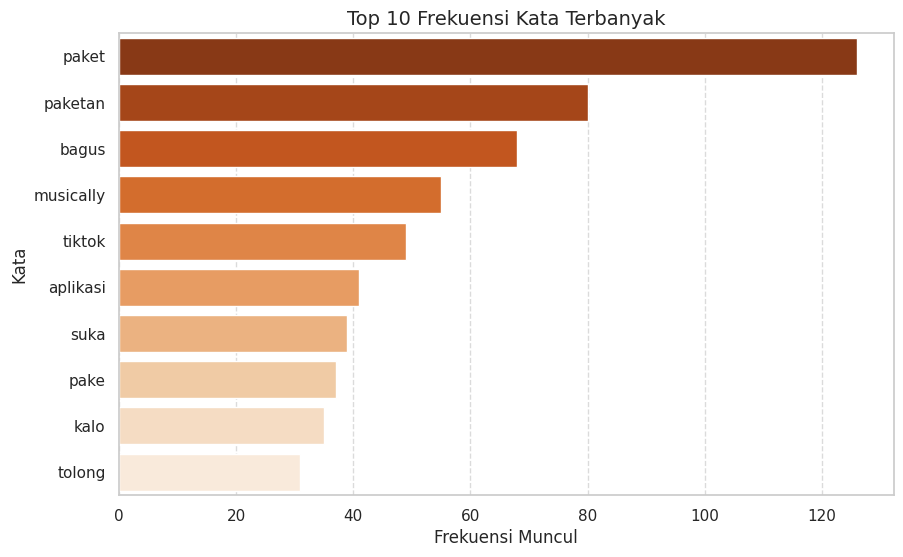

In [178]:
all_words = ' '.join(df['pembersihan_word'].astype(str)).split()

# Menghitung frekuensi kata
word_freq = Counter(all_words)
top_10_words = pd.DataFrame(word_freq.most_common(10), columns=['Kata', 'Jumlah'])

# Plot Grafik Top 10 Kata
plt.figure(figsize=(10, 6))
sns.barplot(x='Jumlah', y='Kata', hue='Kata', data=top_10_words, palette='Oranges_r', legend=False)
plt.title('Top 10 Frekuensi Kata Terbanyak', fontsize=14)
plt.xlabel('Frekuensi Muncul')
plt.ylabel('Kata')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

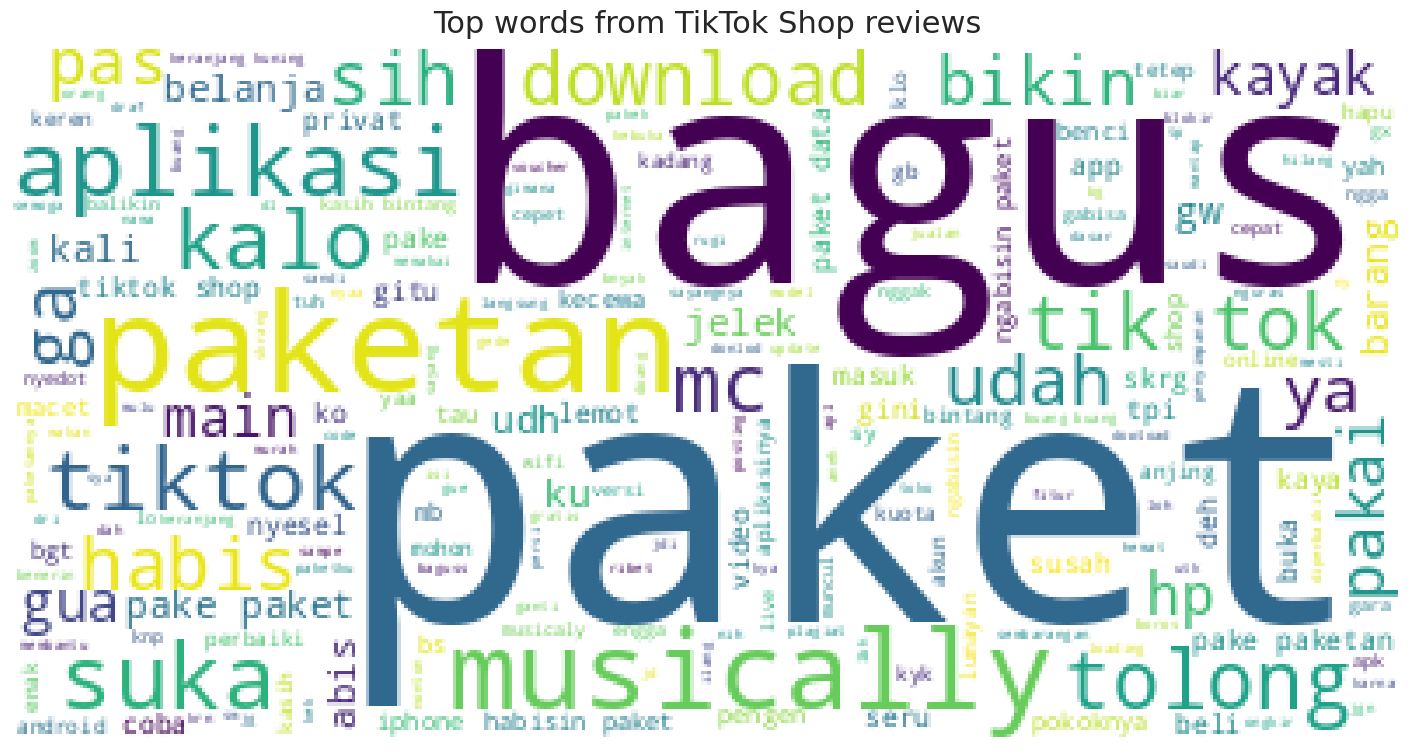

In [179]:
from PIL import Image
import numpy as np

# Note: The original image path '/kaggle/input/masksforwordclouds/twitter_mask3.jpg' was specific to Kaggle
# and caused a FileNotFoundError in this Colab environment. Removing the mask for now.
# If you wish to use a mask, please upload your image to Colab and update the path.

# twitter_mask = np.array(Image.open('/kaggle/input/masksforwordclouds/twitter_mask3.jpg')) # This line caused the error

wc = WordCloud(
    background_color='white',
    max_words=200,
    # mask=twitter_mask, # Mask parameter removed
)

# Generating word cloud from 'pembersihan_word' column, which was created previously
wc.generate(' '.join(text for text in df['pembersihan_word'].astype(str)))

plt.figure(figsize=(18,10))
plt.title('Top words from TikTok Shop reviews',
          fontdict={'size': 22,  'verticalalignment': 'bottom'})
plt.imshow(wc)
plt.axis("off")
plt.show()

/tmp/ipykernel_4709/1637938609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score', data=df, palette='viridis')


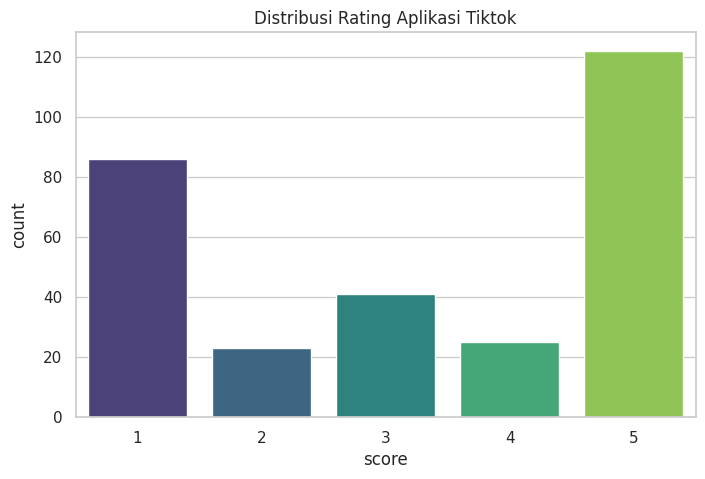

In [164]:
plt.figure(figsize=(8, 5))
sns.countplot(x='score', data=df, palette='viridis')
plt.title('Distribusi Rating Aplikasi Tiktok')
plt.show()

ANALISIS SENTIMEN

In [165]:
!pip install transformers torch

In [166]:
import pandas as pd

# Create 'rating_sentiment' based on the 'score' column in df_absa
def get_rating_sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

df_absa['rating_sentiment'] = df_absa['score'].apply(get_rating_sentiment)

# 1. Menghitung jumlah tiap sentimen dari RATING BINTANG ASLI (Belum pakai IndoRoBERTa)
# Pastikan nama kolomnya sesuai dengan kodemu (biasanya 'rating_sentiment')
jumlah_asli = df_absa['rating_sentiment'].value_counts()

# 2. Menghitung persentase
persentase_asli = (jumlah_asli / len(df_absa) * 100).round(2)

# 3. Menggabungkan ke dalam format Tabel
tabel_distribusi_asli = pd.DataFrame({
    'Sentimen (Rating Asli)': jumlah_asli.index,
    'Jumlah Ulasan': jumlah_asli.values,
    'Persentase (%)': persentase_asli.values
})

# 4. Menambahkan baris "Total"
tabel_distribusi_asli.loc['Total'] = ['Total Keseluruhan', tabel_distribusi_asli['Jumlah Ulasan'].sum(), 100.00]

# 5. Merapikan index tabel
tabel_distribusi_asli = tabel_distribusi_asli.reset_index(drop=True)

# 6. Menampilkan tabel
print("="*60)
print("TABEL DISTRIBUSI SENTIMEN ASLI (DARI RATING PLAY STORE)")
print("="*60)
display(tabel_distribusi_asli)

TABEL DISTRIBUSI SENTIMEN ASLI (DARI RATING PLAY STORE)


,Sentimen (Rating Asli),Jumlah Ulasan,Persentase (%)
0,Positif,172,48.04
1,Negatif,138,38.55
2,Netral,48,13.41
3,Total Keseluruhan,358,100.00


In [167]:
import pandas as pd
from tqdm.notebook import tqdm

from transformers import pipeline
import torch

print("Memuat Model...")
# Sentimen dengan IndoBERTa
model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"
# (Jika model di atas suatu saat bermasalah, alternatif ke-2: "mdhugol/indonesia-bert-sentiment-analysis")

# Deteksi apakah menggunakan GPU (cuda:0) atau CPU (-1)
device = 0 if torch.cuda.is_available() else -1

# Inisialisasi pipeline HuggingFace
nlp_sentimen = pipeline(
    "sentiment-analysis",
    model=model_name,
    tokenizer=model_name,
    device=device
)
print("Model berhasil dimuat!")

# Fungsi untuk memprediksi sentimen
def prediksi_sentimen(teks):
    try:
        # Memotong teks jika terlalu panjang (batas token adalah 512)
        teks = str(teks)[:500]
        hasil = nlp_sentimen(teks)[0]
        return hasil['label']
    except:
        return "Error"

# Terapkan prediksi ke dataframe
print("Mulai menganalisis sentimen...")
# Menggunakan .progress_apply dari tqdm untuk melihat progress
tqdm.pandas()
df_absa['prediksi_sentimen'] = df_absa['pembersihan_text'].progress_apply(prediksi_sentimen)

# Menyeragamkan label
mapping_label = {
    'positive': 'Positif',
    'LABEL_1': 'Positif',
    'LABEL_2': 'Positif', # Beberapa model pakai label 2 untuk positif
    'negative': 'Negatif',
    'LABEL_0': 'Negatif',
    'neutral': 'Netral'
}
df_absa['prediksi_sentimen'] = df_absa['prediksi_sentimen'].replace(mapping_label)

# Tampilkan hasil
df_absa[['pembersihan_text', 'aspek', 'prediksi_sentimen']].head()

Memuat Model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model berhasil dimuat!
Mulai menganalisis sentimen...


  0%|          | 0/358 [00:00<?, ?it/s]

,pembersihan_text,aspek,prediksi_sentimen
0,mengapa tidak ada etalase keranjang kuningnya,Umum,Negatif
1,kenapa yah aplikasi tiktok saya tdak muncul ke...,Sistem Aplikasi,Negatif
2,shop ny tiba hilang saya jadi gak bisa pesan o...,Umum,Netral
3,sangat berguna sekali utk mengetahui infirmasi...,Umum,Positif
4,nginstalnya makan paket banyak semua banyakk t...,Pengiriman,Negatif


In [143]:
# Hasil Sentimen IndoBERTa
# 'prediksi_sentimen' column already exists in df_absa from the previous sentiment analysis step

print(df_absa['prediksi_sentimen'].value_counts())
print(df_absa.groupby('prediksi_sentimen')['score'].mean())

prediksi_sentimen
Negatif    225
Positif     92
Netral      41
Name: count, dtype: int64
prediksi_sentimen
Negatif    2.560000
Netral     3.439024
Positif    4.576087
Name: score, dtype: float64


In [145]:
import pandas as pd

# 1. Menghitung jumlah tiap sentimen dari hasil prediksi IndoRoBERTa
jumlah_sentimen = df_absa['prediksi_sentimen'].value_counts()

# 2. Menghitung persentase
persentase_sentimen = (jumlah_sentimen / len(df_absa) * 100).round(2)

# 3. Menggabungkan ke dalam format Tabel (DataFrame Pandas)
tabel_distribusi = pd.DataFrame({
    'Sentimen': jumlah_sentimen.index,
    'Jumlah Ulasan': jumlah_sentimen.values,
    'Persentase (%)': persentase_sentimen.values
})

# 4. Menambahkan baris "Total" di bagian paling bawah
tabel_distribusi.loc['Total'] = ['Total Keseluruhan', tabel_distribusi['Jumlah Ulasan'].sum(), 100.00]

# 5. Merapikan index tabel agar urut
tabel_distribusi = tabel_distribusi.reset_index(drop=True)

# 6. Menampilkan tabel
print("="*55)
print("TABEL DISTRIBUSI SENTIMEN (PREDIKSI INDOROBERTA)")
print("="*55)
display(tabel_distribusi)

TABEL DISTRIBUSI SENTIMEN (PREDIKSI INDOROBERTA)


,Sentimen,Jumlah Ulasan,Persentase (%)
0,Negatif,225,62.85
1,Positif,92,25.70
2,Netral,41,11.45
3,Total Keseluruhan,358,100.00


EVALUASI

In [148]:
# Create 'rating_sentiment' based on the 'score' column in df_absa
def get_rating_sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

df_absa['rating_sentiment'] = df_absa['score'].apply(get_rating_sentiment)

# Find mismatches where rating_sentiment is 'Positif' but prediksi_sentimen is 'Negatif'
mismatch = df_absa[
    (df_absa['rating_sentiment'] == 'Positif') &
    (df_absa['prediksi_sentimen'] == 'Negatif') &
    (df_absa['pembersihan_text'].str.split().str.len() >= 5) # Corrected column name
]

if not mismatch.empty:
    print("Ulasan dengan rating positif namun diprediksi negatif oleh model:")
    display(mismatch[['pembersihan_text', 'rating_sentiment', 'prediksi_sentimen']]) # Corrected column name
else:
    print("Tidak ditemukan ulasan yang ratingnya positif tetapi diprediksi negatif.")

# Find mismatches where rating_sentiment is 'Negatif' but prediksi_sentimen is 'Positif'
mismatch_neg_pos = df_absa[
    (df_absa['rating_sentiment'] == 'Negatif') &
    (df_absa['prediksi_sentimen'] == 'Positif') &
    (df_absa['pembersihan_text'].str.split().str.len() >= 5) # Corrected column name
]

if not mismatch_neg_pos.empty:
    print("\nUlasan dengan rating negatif namun diprediksi positif oleh model:")
    display(mismatch_neg_pos[['pembersihan_text', 'rating_sentiment', 'prediksi_sentimen']]) # Corrected column name
else:
    print("\nTidak ditemukan ulasan yang ratingnya negatif tetapi diprediksi positif.")

Ulasan dengan rating positif namun diprediksi negatif oleh model:


,pembersihan_text,rating_sentiment,prediksi_sentimen
6,kenapa versi asia gaada tiktok shopnya,Positif,Negatif
9,gimana cara nya betulin tiktok pusat belanja n...,Positif,Negatif
12,app bagus tp boros ke paket internet nya doang,Positif,Negatif
20,ini aplikasi apaan gw ingin belanja di shop ta...,Positif,Negatif
21,kenapa cod di tiktok ku gak bisa biasanya ok a...,Positif,Negatif
...,...,...,...
338,bagus banget tapi ngehabisin paketan,Positif,Negatif
340,kok aku coba dua hari atau tiga hari sudah abi...,Positif,Negatif
341,sebenernya aplikasi ini bagus banget malah tap...,Positif,Negatif
342,sebenernya aplikasi ini bagus banget malah tap...,Positif,Negatif



Ulasan dengan rating negatif namun diprediksi positif oleh model:


,pembersihan_text,rating_sentiment,prediksi_sentimen
76,saya memberi bintang dua kerena banyak paket u...,Negatif,Positif
268,mainin harul pakei paket walaupun enak,Negatif,Positif
306,musical ly yg dulu kayaknya lebih bagus karna ...,Negatif,Positif


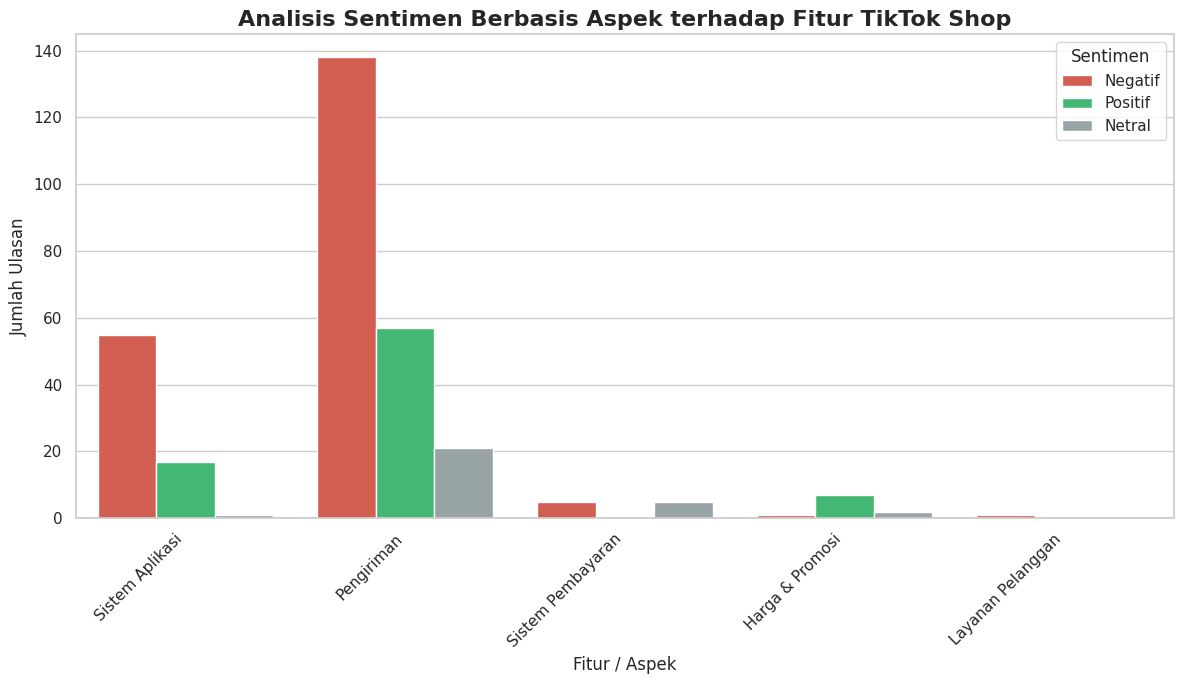


Persentase Sentimen per Aspek (%):
prediksi_sentimen  Negatif  Netral  Positif
aspek                                      
Harga & Promosi      10.00   20.00    70.00
Layanan Pelanggan   100.00    0.00     0.00
Pengiriman           63.89    9.72    26.39
Sistem Aplikasi      75.34    1.37    23.29
Sistem Pembayaran    50.00   50.00     0.00
Umum                 52.08   25.00    22.92


In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# Membuat chart batang untuk melihat sentimen pada setiap aspek
ax = sns.countplot(
    data=df_absa[df_absa['aspek'] != 'Umum'], # Abaikan kategori Umum untuk fokus ke fitur
    x='aspek',
    hue='prediksi_sentimen',
    palette={'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#95a5a6'}
)

plt.title('Analisis Sentimen Berbasis Aspek terhadap Fitur TikTok Shop', fontsize=16, fontweight='bold')
plt.xlabel('Fitur / Aspek', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen')
plt.tight_layout()

plt.show()

# Menampilkan persentase kepuasan per aspek
crosstab = pd.crosstab(df_absa['aspek'], df_absa['prediksi_sentimen'], normalize='index') * 100
print("\nPersentase Sentimen per Aspek (%):")
print(crosstab.round(2))

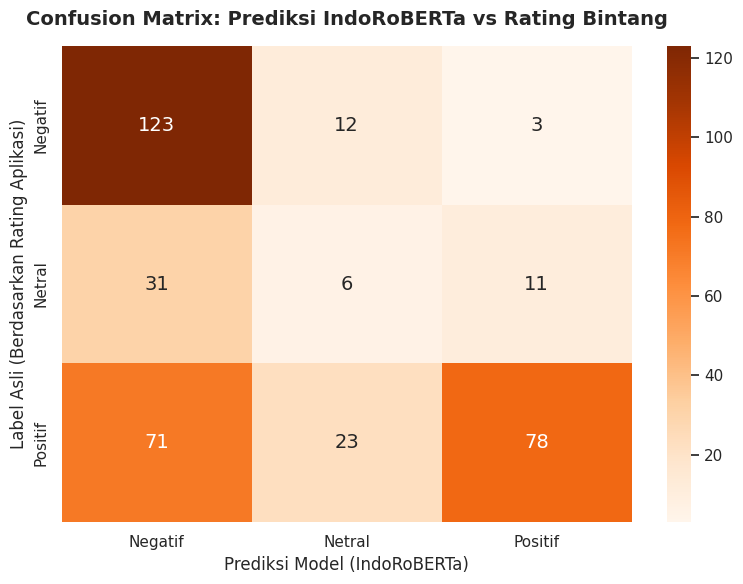


LAPORAN KLASIFIKASI (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

     Negatif       0.55      0.89      0.68       138
      Netral       0.15      0.12      0.13        48
     Positif       0.85      0.45      0.59       172

    accuracy                           0.58       358
   macro avg       0.51      0.49      0.47       358
weighted avg       0.64      0.58      0.56       358



In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Menggunakan rating_sentiment sebagai Kunci Jawaban (Ground Truth)
y_true = df_absa['rating_sentiment']
y_pred = df_absa['prediksi_sentimen']

# Pastikan urutan labelnya seragam
labels = ['Negatif', 'Netral', 'Positif']

# Menghitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Membuat Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 14})

# Mempercantik Judul dan Label
plt.title('Confusion Matrix: Prediksi IndoRoBERTa vs Rating Bintang', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Prediksi Model (IndoRoBERTa)', fontsize=12)
plt.ylabel('Label Asli (Berdasarkan Rating Aplikasi)', fontsize=12)
plt.tight_layout()
plt.show()

# Menampilkan Tabel Akurasi untuk Skripsi
print("\n" + "="*50)
print("LAPORAN KLASIFIKASI (CLASSIFICATION REPORT)")
print("="*50)
print(classification_report(y_true, y_pred, labels=labels))